<a href="https://colab.research.google.com/github/Technophobe01/AAAMLP/blob/main/Copy_of_%5B2026_03_04%5D_SIS_Lab_Manual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Getting Started**

# **`PLEASE EXECUTE THE FOLLOWING STEPS WITHOUT FAIL`**

<br>

📄 **`STEP 1:` Create a Copy**

> * Go to `File` > Save a copy in Drive
> * Close the original tab
> * In the new copy, simply click on the name to rename
> * Rename to something unique of your choice

<br>

📄 **`STEP 2:` Log into SIS Lab Command Org**

> Click [HERE](https://vce-sis-api.command.verkada.com) to access the Lab Command Org
> *   Email: `Same` as you signed in with via `QR code` or a `Link` provided by your trainer
> *   Password: Click `Forget Password` and create a new one

<br>

📄 **`STEP 3:` Run the Code Below**

> * Run the following two cell blocks
> * You should see a token printed after running the second block


In [ ]:
from random import randint

# Assign yourself a unique random number for the rest of the session
your_number = randint(0, 10000)

print(f'Your unique number is {your_number}')

Your unique number is 6596


In [ ]:
import requests

# VCE Trainers to update the key below
# Inform attendees to not create one for themselves

API_KEY = "N2Q5YjQzYTYtNmM4OC00ZmZkLWFiYzUtZjZmNzI1Nzg5Nzc5fDhkZjk2OThlLTQ5ZmQtNDU5ZC1iMGQ0LTg0MWQyMTMyMjg4Nw=="

# Defining a function to set token when called
def set_token():

  url = "https://api.verkada.com/token"

  headers = {
      "accept": "application/json",
      "x-api-key": API_KEY
  }

  response = requests.post(url, headers=headers)
  response = response.json()

  return response['token']


# Calling the function when in need of a token
set_token()

'v2_4709387d28bb679aef12b383041bd822'

# Section 1 - Verkada APIs



### 🛑 *Halt The Heist*

> **Alert:** A disgruntled employee has compromised your customer's security apparatus.  

> 🔐 Your mission: Secure the Command org using `APIs only`




## 1.1 Viewing Station API

> ▹ ***Objective:***

> Confirm that the security team's Viewing Stations still remain in the Command org

In [ ]:
import requests
from pprint import pprint

#Define the endpoint
url = "https://api.verkada.com/viewing_station/v1/devices"

headers = {
    "accept": "application/json",
    "x-verkada-auth": set_token()
}

response = requests.get(url, headers=headers)
response = response.json()
pprint(response)

{'devices': [{'app_version': None,
              'claimed_serial_number': 'DRJ9-YX3K-H6EW',
              'device_id': '7180eb8a-f47a-4290-b714-7f6599cbe625',
              'ip_address': '',
              'last_seen_at': None,
              'last_status': 'offline',
              'location': '406 E 3rd Ave, San Mateo, CA 94401, USA',
              'location_lat': 37.56613979999999,
              'location_lon': -122.3210929,
              'name': 'Viewing Station Demo Space',
              'site_id': '22471bae-41aa-4d49-94de-f010618422d4',
              'timezone': 'America/Los_Angeles'},
             {'app_version': None,
              'claimed_serial_number': 'DRJY-TFKG-AHNK',
              'device_id': '2704d770-084e-44a4-ab15-02e9604fd158',
              'ip_address': '',
              'last_seen_at': None,
              'last_status': 'offline',
              'location': '406 E 3rd Ave, San Mateo, CA 94401, USA',
              'location_lat': 37.56613979999999,
              'loca

In [ ]:
# Print station names with serial numbers
for device in response['devices']:
    name = device['name']
    serial = device['claimed_serial_number']
    print(f"{name} \n {serial} \n")

Viewing Station Demo Space 
 DRJ9-YX3K-H6EW 

Viewing Station Lobby 
 DRJY-TFKG-AHNK 

Viewing Station Security Hut 
 DRJW-GEDJ-FAXH 



**Bonus Activity #1**

In [ ]:
# BONUS

# What would the following JSON path return?

response['devices'][1]['device_id']

'2704d770-084e-44a4-ab15-02e9604fd158'

## 1.2 Sensor Data API

> ▹ ***Objective:***

> Verify the integrity of the servers by calculating average temperatures of the server room for the last week
> * `🧊 Too Cold?` < 72F - Some necessary services may have been stopped!<br>
> * `🔥 Too Hot?` > 76F - The servers may be overloaded!


In [ ]:
from datetime import datetime, timedelta

# Take a datetime value and converts it to a unix timestamp
def convert_to_unix_timestamp(timestamp):
  return round((timestamp - datetime(1970, 1, 1)).total_seconds())

# Calculate the human understandable timestamp
current_timestamp = datetime.now()
last_week_timestamp = current_timestamp - timedelta(days=2)

# Calculate the UNIX timestamp
current_unix_timestamp = convert_to_unix_timestamp(current_timestamp)
last_week_unix_timestamp = convert_to_unix_timestamp(last_week_timestamp)

# Define parameters
device_id = "b387d736-21f7-4d75-9307-aa2a6e46266e"
measurement = "temperature" # Changed from carbon_dioxide to temperature
start_time = last_week_unix_timestamp
end_time = current_unix_timestamp
interval = "30m"

# Make the API call
url = f"https://api.verkada.com/environment/v1/data?device_id={device_id}&start_time={start_time}&end_time={end_time}&page_size=200&fields={measurement}&interval={interval}"

headers = {
    "accept": "application/json",
    "x-verkada-auth": set_token()
}

response = requests.get(url, headers=headers)
response = response.json()
pprint(response)

{'data': [{'temperature': 26.451568603515625, 'time': 1772470800},
          {'temperature': 26.673202514648438, 'time': 1772472600},
          {'temperature': 26.694564819335938, 'time': 1772474400},
          {'temperature': 26.878814697265625, 'time': 1772476200},
          {'temperature': 27.084426879882812, 'time': 1772478000},
          {'temperature': 27.076416015625, 'time': 1772479800},
          {'temperature': 27.20458984375, 'time': 1772481600},
          {'temperature': 27.458267211914062, 'time': 1772483400},
          {'temperature': 27.669219970703125, 'time': 1772485200},
          {'temperature': 27.634506225585938, 'time': 1772487000},
          {'temperature': 27.786712646484375, 'time': 1772488800},
          {'temperature': 27.671890258789062, 'time': 1772490600},
          {'temperature': 27.562408447265625, 'time': 1772492400},
          {'temperature': 27.586441040039062, 'time': 1772494200},
          {'temperature': 27.490310668945312, 'time': 1772496000},
  

In [ ]:
# Extract only the temperature readings
running_temp_log = []

for data in response['data']:
  running_temp_log.append(data['temperature'])

print(running_temp_log)

[26.451568603515625, 26.673202514648438, 26.694564819335938, 26.878814697265625, 27.084426879882812, 27.076416015625, 27.20458984375, 27.458267211914062, 27.669219970703125, 27.634506225585938, 27.786712646484375, 27.671890258789062, 27.562408447265625, 27.586441040039062, 27.490310668945312, 27.503662109375, 27.522354125976562, 27.402191162109375, 27.276687622070312, 27.327423095703125, 27.298049926757812, 27.081756591796875, 26.982955932617188, 26.857452392578125, 26.742630004882812, 26.729278564453125, 26.649169921875, 26.534347534179688, 26.515655517578125, 26.398162841796875, 26.240615844726562, 26.213912963867188, 26.04034423828125, 26.010971069335938, 25.91217041015625, 25.840072631835938, 25.714569091796875, 25.714569091796875, 25.65582275390625, 25.669174194335938, 25.765304565429688, 25.792007446289062, 25.84808349609375, 25.8587646484375, 25.9442138671875, 25.936203002929688, 25.83740234375, 25.960235595703125, 26.037673950195312, 26.280670166015625, 26.462249755859375, 26.6

In [ ]:
# Calculate the average temperature (will always be in Celsius)
average_temp_celsius = sum(running_temp_log) / len(running_temp_log)

# Convert it to Fahrenheit
average_temp_fahrenheit = (average_temp_celsius * 9/5) + 32

# Print the temperature
print(f"Server room temperature: {average_temp_fahrenheit:.2f}")

# Determine if the temperature is within optimal range or not
if average_temp_fahrenheit > 76:
  print("Servers running hotter than normal")

elif average_temp_fahrenheit < 72:
    print("Servers running cooler than normal")

else:
  print("Temperature optimal.")

Server room temperature: 79.63
Servers running hotter than normal


**Bonus Activity #2**


In [ ]:
# BONUS

# Instead of temperature, try printing CO2 readings from the past 2 days in intervals of 30 minutes


## 1.3 Camera POI API

> ▹ ***Objective:***

> Add the disgruntled employee to the customer's POI database<br>



📸 **STEP 1:** Grab an image from [thispersondoesnotexist](https://thispersondoesnotexist.com/) and encode it as `Base64`


In [ ]:
import requests
import base64

URL_TO_ENCODE = "https://thispersondoesnotexist.com"

# Fetches an image from a URL and encodes it into a Base64 string
def encode_image_from_url(image_url):

    try:
        # Send an HTTP GET request to the image URL
        # The stream=True is good practice for downloading binary content
        response = requests.get(image_url, stream=True)

        # Get the raw binary content of the image from the response
        image_content = response.content

        # Encode the binary content to Base64 which will return a bytes object
        # Bytes is not a native datatype in Python so its not really useful to us
        base64_encoded_bytes = base64.b64encode(image_content)

        # Decode the Base64 bytes object into a standard UTF-8 string
        # This will convert Bytes into String which is a native dataype in Python
        base64_encoded_string = base64_encoded_bytes.decode('utf-8')

        return base64_encoded_string

    except requests.exceptions.RequestException as e:
        print(f"Error: Could not fetch the image from the URL. Details: {e}")
        return None

    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return None

# Call the function to get the encoded string.
encoded_string = encode_image_from_url(URL_TO_ENCODE)

print("Base64 Encoded String (first 100 characters):\n")
print(encoded_string[:100] + "...")

Base64 Encoded String (first 100 characters):

/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEB...




👤 **STEP 2:** Upload our `encoded_string` and create a POI!

In [ ]:
import requests
from pprint import pprint

url = "https://api.verkada.com/cameras/v1/people/person_of_interest"

name = input("Name your POI: ")

payload = {
    "label": f'{your_number} {name}',
    "base64_image": encoded_string
}

headers = {
    "accept": "application/json",
    "content-type": "application/json",
    "x-verkada-auth": set_token()
}

response = requests.post(url, json=payload, headers=headers)

pprint(response.json())

Name your POI: /9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEB...
{'created': 1772642864,
 'label': '6596 '
          '/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEBAQEB...',
 'last_seen': 0,
 'person_id': '13a302ab-7c24-4f31-8717-b2dab2e9b888'}


**Bonus Activity #3**


In [ ]:
# BONUS

# Visit apidocs.verkada.com and make the 'GET All People of Interest' call
  # Verify the POI you made previously is present in the output


## 1.4 Core Command API

> ▹ ***Objective:***

> Our disgruntled employee removed the security team from Command, add them back!<br>

> 🪪 **Security Guard 1**<br>
>  * Name: {your_number} Pat Down<br>
>  * Email: pat{your_number}@example.com<br>

In [ ]:
import requests
from pprint import pprint

url = "https://api.verkada.com/core/v1/user"

payload = {
    "email": f"pat{your_number}@example.com",
    "first_name": f"{your_number} Pat",
    "last_name": "Down"
}

headers = {
    "accept": "application/json",
    "content-type": "application/json",
    "x-verkada-auth": set_token()
}

response = requests.post(url, json=payload, headers=headers)

pprint(response.json())

{'active': True,
 'company_name': None,
 'department': None,
 'department_id': None,
 'email': 'pat6596@example.com',
 'employee_id': None,
 'employee_title': None,
 'employee_type': None,
 'external_id': None,
 'first_name': '6596 Pat',
 'last_name': 'Down',
 'middle_name': None,
 'phone': None,
 'user_id': '861e684e-b6bd-4245-912f-e782ae733347'}


> 🪪 **Security Guard 2**<br>
>  * Name: {your_number} Louise Law<br>
>  * Email: louise{your number}@example.com<br>

> 🪪 **Security Guard 3**<br>
>  * Name: {your_number} Buzz Kill<br>
>  * Email: buzz{your number}@example.com<br>

> 🪪 **Security Guard 4**<br>
>  * Name: {your_number} Judy Judge<br>
>  * Email: judy{your number}@example.com<br>

In [ ]:
import requests

# List of users
users = [
    {
        "email": f"louise{your_number}@example.com",
        "first_name": f"{your_number} Louise",
        "last_name": "Law"
    },
    {
        "email": f"buzz{your_number}@example.com",
        "first_name": f"{your_number} Buzz",
        "last_name": "Kill"
    },
    {
        "email": f"judy{your_number}@example.com",
        "first_name": f"{your_number} Judy",
        "last_name": "Judge"
    }
]

# Function to add a user
def add_user(email, first_name, last_name):

    url = "https://api.verkada.com/core/v1/user"

    payload = {
        "email": email,
        "first_name": first_name,
        "last_name": last_name
    }

    headers = {
        "accept": "application/json",
        "content-type": "application/json",
        "x-verkada-auth": set_token()
    }

    response = requests.post(url, json=payload, headers=headers)

    if response.status_code == 200:
      print(f"Added {first_name} {last_name}")
    else:
      message = response.json()["message"]
      print(f"Error!\nStatus code: {response.status_code}\n{message} \n")

# Loop through and add each user
for user in users:
  add_user(user["email"], user["first_name"], user["last_name"])


Added 6596 Louise Law
Added 6596 Buzz Kill
Added 6596 Judy Judge


**Bonus Activity #4**


In [ ]:
# BONUS

# If you try to run the cell block above again you may receive an "unknown error", why do you think that is?


## 1.5 Access Control Door Exceptions API

> ▹ ***Objective:***

> Integrate your customer's internal system so that employees must book rooms in order to unlock them!


📄 **STEP 1:** Save the file [Test_Meetings](https://docs.google.com/spreadsheets/d/1UhDtF-F736pyoxK_PQtfCh_2iGp6YvsODIMhPsMlqV4/edit?usp=sharing) as a **CSV** and convert to a `pandas DataFrame`

In [ ]:
import pandas as pd
from google.colab import files

# Upload CSV file manually
uploaded = files.upload()

# Get the uploaded file name (assumes only one file uploaded)
csv_filename = list(uploaded.keys())[0]

# Convert to pandas DataFrame
df = pd.read_csv(csv_filename)
print("\n")
print(df)

Saving Test_Meetings - Sheet1 (1).csv to Test_Meetings - Sheet1 (1).csv


                   meeting_name meeting_room        date start_time end_time
0      Product Team Weekly Sync       Door 6  2026-03-04       9:00    10:00
1  West Corp Team Sales Kickoff       Door 8  2026-03-04      10:00    12:00
2  Platform Team SCRUM Planning       Door 7  2026-03-04      13:00    14:00
3           Interview: Jane Doe       Door 5  2026-03-04      13:00    13:30


📄 **STEP 2:** `GET` all doors in the org and correlate `meeting_room` with `door_id`

In [ ]:
import requests

url = "https://api.verkada.com/access/v1/doors"

headers = {
    "accept": "application/json",
    "x-verkada-auth": set_token()
}

response = requests.get(url, headers=headers)
response = response.json()

pprint(response)

{'doors': [{'acu_id': '4ae6cd0e-cbd1-4ed3-b330-79eeb16a3e45',
            'acu_name': 'Doors 9-10',
            'api_control_enabled': True,
            'camera_info': {'inside_camera_id': None,
                            'intercom_camera_id': None,
                            'outside_camera_id': None},
            'door_id': '6bd70d32-b856-4ebf-b6bb-6c0a512a9fd5',
            'name': 'Door 9',
            'site': {'name': 'HQ',
                     'site_id': '22471bae-41aa-4d49-94de-f010618422d4'},
            'timezone': 'America/Los_Angeles'},
           {'acu_id': '4ae6cd0e-cbd1-4ed3-b330-79eeb16a3e45',
            'acu_name': 'Doors 9-10',
            'api_control_enabled': True,
            'camera_info': {'inside_camera_id': None,
                            'intercom_camera_id': None,
                            'outside_camera_id': None},
            'door_id': '436c4087-2cc3-4bf3-95ba-4047dbdd49a9',
            'name': 'Door 10',
            'site': {'name': 'HQ',
        

In [ ]:
# Create a lookup dict: door name → door ID
door_lookup = {}

for door in response['doors']:
  door_lookup.update({
          door['name']: door['door_id']
      })

print("Lookup Dictionary\n")
pprint(door_lookup)

Lookup Dictionary

{'Door 1': '530c53e7-90fa-4ea8-a896-5f249248944a',
 'Door 10': '436c4087-2cc3-4bf3-95ba-4047dbdd49a9',
 'Door 2': 'd39e4ea0-c9b3-4d4d-86af-ca991a6db97e',
 'Door 3': '11f19ac6-7ce1-41fb-99c8-6f8bbf628c6b',
 'Door 4': '4e75035f-4137-4fa1-a559-f39bbf38a006',
 'Door 5': '373ada76-651b-4e98-ad69-40ae852111a3',
 'Door 6': 'efa118b2-e93d-4c4c-9407-79ad2ab4e0d4',
 'Door 7': 'd8b6d1c5-bade-4022-862b-7fc42067aa7e',
 'Door 8': 'ed7739dc-bf39-471d-976e-0a96f69e6f0f',
 'Door 9': '6bd70d32-b856-4ebf-b6bb-6c0a512a9fd5'}


In [ ]:
# Ensure meeting_room is string so it matches the keys in door_lookup

# Map the door IDs into a new column
df['door_id'] = df['meeting_room'].map(door_lookup)

# Done!
print(df)

                   meeting_name meeting_room        date start_time end_time  \
0      Product Team Weekly Sync       Door 6  2026-03-04       9:00    10:00   
1  West Corp Team Sales Kickoff       Door 8  2026-03-04      10:00    12:00   
2  Platform Team SCRUM Planning       Door 7  2026-03-04      13:00    14:00   
3           Interview: Jane Doe       Door 5  2026-03-04      13:00    13:30   

                                door_id  
0  efa118b2-e93d-4c4c-9407-79ad2ab4e0d4  
1  ed7739dc-bf39-471d-976e-0a96f69e6f0f  
2  d8b6d1c5-bade-4022-862b-7fc42067aa7e  
3  373ada76-651b-4e98-ad69-40ae852111a3  


📄 **STEP 3:** Create Door Calendar Exceptions for each meeting, shifting the door from "locked" to "access-controlled"

In [ ]:
import requests

# Function to create Door Exception using key attributes
def create_door_exception(meeting_name, door_id, date, end_time, start_time):

  url = "https://api.verkada.com/access/v1/door/exception_calendar"

  payload = {
      "doors": [door_id],
      "exceptions": [
          {
              "date": date,
              "door_status": "access_controlled",
              "end_time": end_time,
              "start_time": start_time
          }
      ],
      "name": f'{your_number} {meeting_name}'
  }

  headers = {
      "accept": "application/json",
      "content-type": "application/json",
      "x-verkada-auth": set_token()
  }

  response = requests.post(url, json=payload, headers=headers)

  if response.status_code == 200:
    print(f"✅ '{your_number} {meeting_name}' booked successfully for {date}!")

  else:
    message = response.json()["message"]
    print(f"Error!\nStatus code: {response.status_code}\n{message}")


# Iterate through each row of table, extract key attributes, and pass into the function call
for index, row_data in df.iterrows():
    create_door_exception(
        door_id = row_data['door_id'],
        date = row_data['date'],
        start_time = row_data['start_time'],
        end_time = row_data['end_time'],
        meeting_name = row_data['meeting_name']
    )

✅ '6596 Product Team Weekly Sync' booked successfully for 2026-03-04!
✅ '6596 West Corp Team Sales Kickoff' booked successfully for 2026-03-04!
✅ '6596 Platform Team SCRUM Planning' booked successfully for 2026-03-04!
✅ '6596 Interview: Jane Doe' booked successfully for 2026-03-04!


# Section 2 - Helix API

📄 **STEP 1:** Download a CSV of our external [Helix_Dataset](https://docs.google.com/spreadsheets/d/1Y74WvNgKa59IeWp8F3vunfot0BL3i5qLmkTjlQuCUZU/edit?usp=sharing) and upload when prompted



In [33]:
from google.colab import files
import csv
import requests

# Upload CSV file manually
uploaded = files.upload()

# Get the uploaded file name (assumes only one file uploaded)
product_prices = list(uploaded.keys())[0]

Saving Helix_Dataset - Sheet1 (1).csv to Helix_Dataset - Sheet1 (1) (1).csv


📄 **STEP 2:** We are going to imitate a transaction coming in from a POS system

In [35]:
# This function is used to imitate a transaction from POS
  # It simply opens the priceList.csv file and fetches a row of data
  # It then stores the values of the attributes in that row into appropriate variables

import csv
import random

def grocery_scan(counter):
    with open(product_prices) as price_list:
        fp = list(csv.DictReader(price_list))
        row = fp[counter]
        category = row['category']
        item = row['item']
        price = row['price']
        timestamp = row['timestamp']
    return category, item, price, timestamp

📄 **STEP 3:** Send our fake transactions to Command via Helix API, in addition to the usual keys and urls we'll need:<br>
>  - Event Attributes (item name, price etc.)<br>
>  - Camera ID<br>
>  - Event Type UID (generate on Command)<br>
>  - Timestamp of Event


      Additionally, configure Helix event on Command
>  - Click on the Bell icon on left sidebar and then + Helix Events<br>
>  - Event Type Name - your name<br>
>  - Event Attributes - exactly as shown below<br>

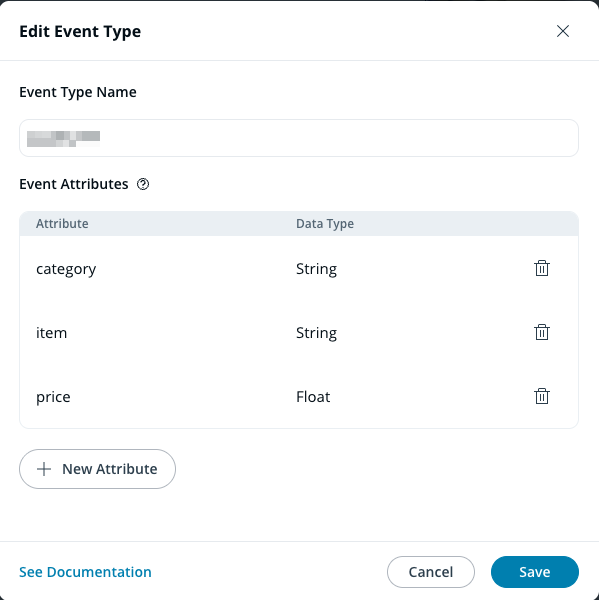

In [36]:
# Set the Event Type UID for the Helix Event you just created
event_type_uid = input("Insert Event Type UID here: ")

# This function sends data from the dataset to the right Helix event on Command
def send_to_helix(category, item, price, timestamp):

  url = "https://api.verkada.com/cameras/v1/video_tagging/event"

  payload = {
      "attributes": {
          "category": category,
          "item": item,
          "price": float(price)
      },
      "flagged": False,
      "camera_id": '2983729f-ff02-42d2-a63c-f4c64fe2ce0c',
      "event_type_uid": event_type_uid,
      "time_ms": timestamp
  }

  headers = {
      "content-type": "application/json",
      "x-verkada-auth": set_token()
  }

  response = requests.post(url, json=payload, headers=headers)

  if response.status_code == 200:
    print("Helix event uploaded successfully!")
  else:
    message = response.json()["message"]
    print(f"Error!\nStatus code: {response.status_code}\n{message}")

Insert Event Type UID here: 20c52fe0-d09b-44a7-bbdd-cd768b7824c0


In [37]:
counter = 0

# Send 5 data entries to Helix

for i in range(5):
  category, item, price, timestamp = grocery_scan(counter)
  send_to_helix(category, item, price, timestamp)
  counter = counter + 1

Helix event uploaded successfully!
Helix event uploaded successfully!
Helix event uploaded successfully!
Helix event uploaded successfully!
Helix event uploaded successfully!


# Section 3 - Webhooks


📄 **STEP 1:** Prepare Webhook Receiver

> Visit [webhook.site](https://webhook.site/) and copy `Your unique URL`






📄 **STEP 2:** Prepare Webhook Sender on Command <br>



1.   Navigate to All Products > Admin > API & Integrations > Webhooks
2.   Click + Add button > General Webhook
3.   Fill out as follows:
> *   Name - Give it a unique name that you can easily locate with
> *   Webhook URL - Paste your unique URL from webhook.site
> *   Shared Secret - something random like abc or verkada123 (could be anything)
> *   Scopes - All Scopes


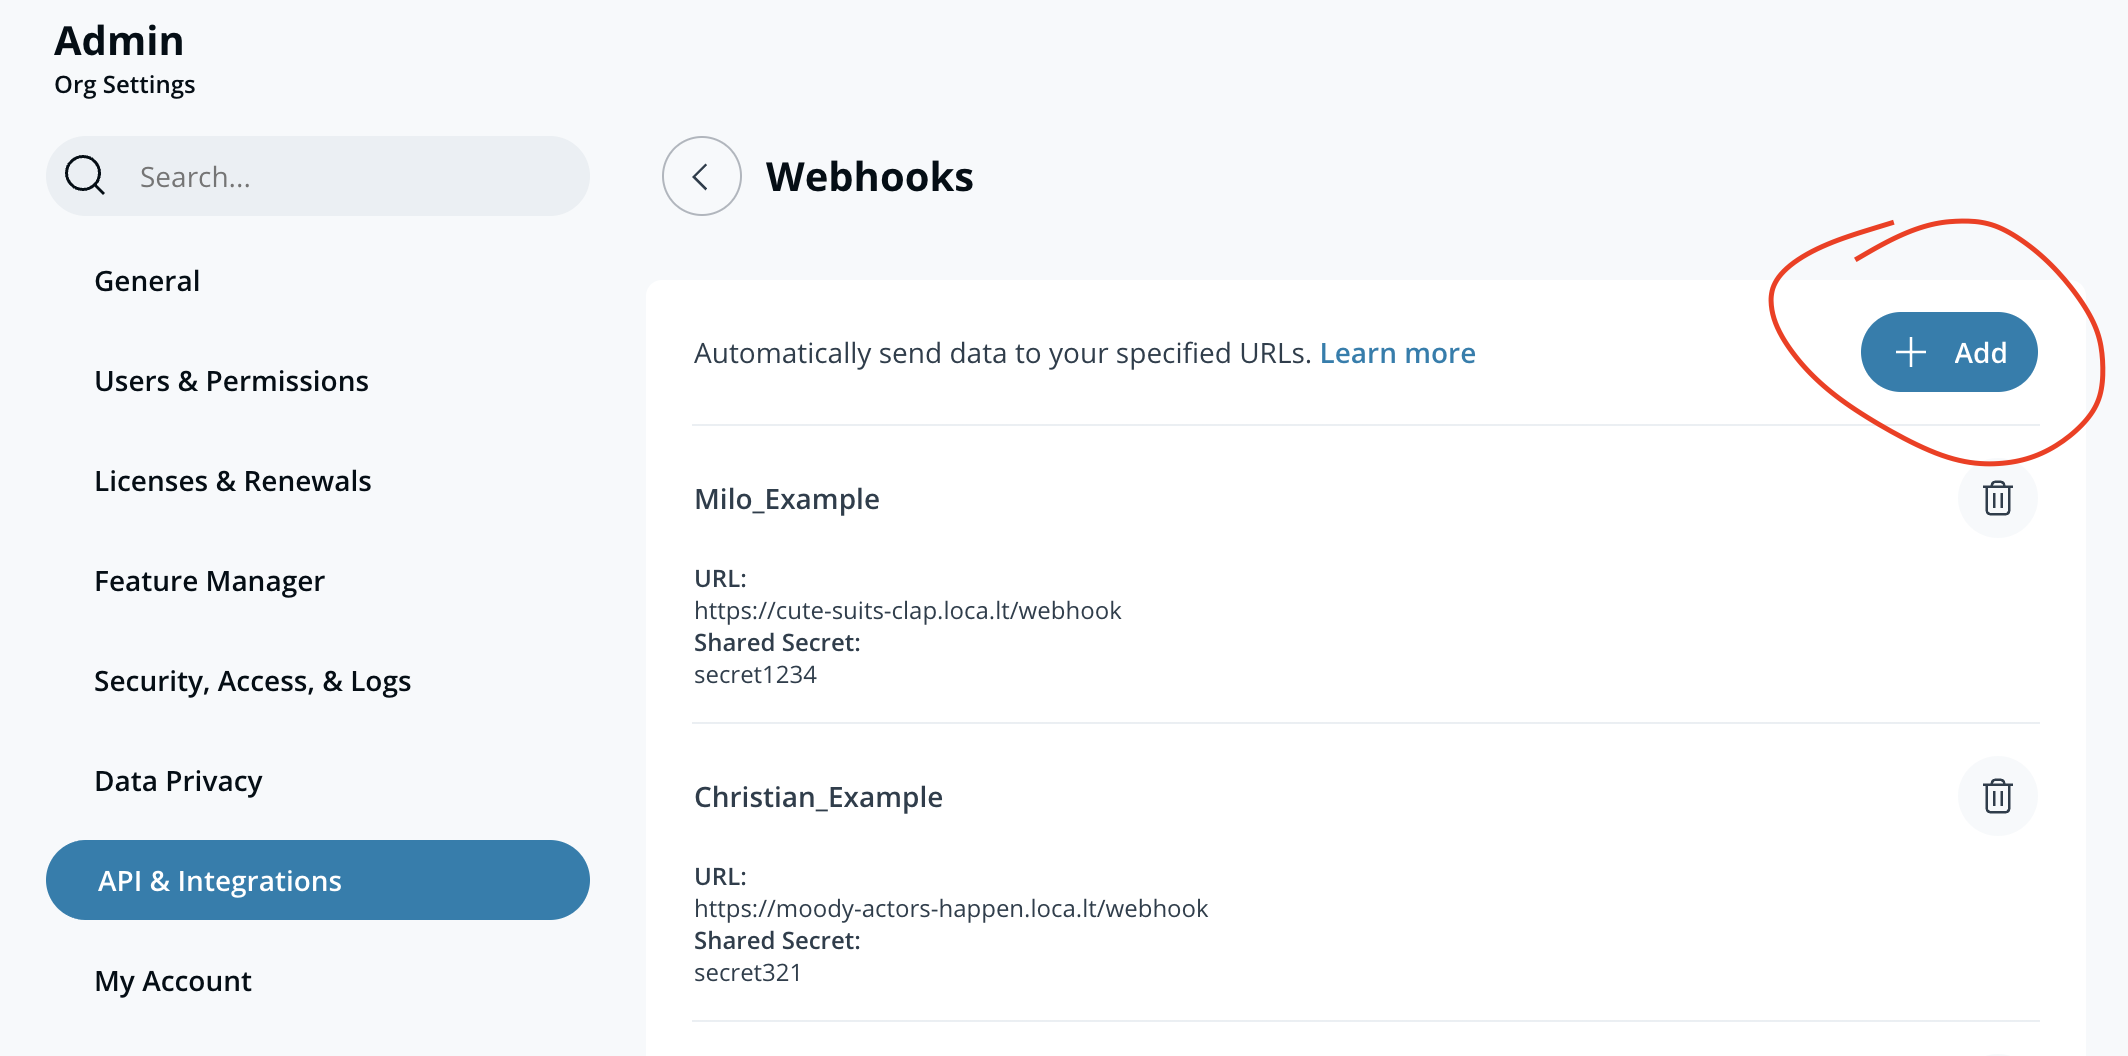






In [38]:
# Open door API call
# We are using this to generate webhook events
def open_door(open_door_id):

  url = "https://api.verkada.com/access/v1/door/admin_unlock"

  payload = {
      "door_id": open_door_id
  }

  headers = {
      "accept": "application/json",
      "content-type": "application/json",
      "x-verkada-auth": set_token()
  }

  response = requests.post(url, json=payload, headers=headers)

  if response.status_code == 200:
    print("Door Opened!")
  else:
    print(f"Call Failed, Code: {response.status_code}")

Determine your door number using [this sheet](https://docs.google.com/spreadsheets/d/1sqbpxqYyt9cfYGaKRFO9rVVBfW9x15N9GuEmB-quo1k/edit?usp=sharing) and the following code will automatically find the corresponding 'door_id' using our 'door_lookup' dictionary from **`Section 1.5`**



In [39]:
door_number = input("Your Door Number Is: ")
door = "Door " + door_number

try:
  open_door_id = door_lookup[door]
  print(f"\n open_door_id = {open_door_id}")
except KeyError:
  print("\n Invalid Door Number!")

Your Door Number Is: 3

 open_door_id = 11f19ac6-7ce1-41fb-99c8-6f8bbf628c6b


In [40]:
# This code run the Open Door API, wait 10 seconds and run again for total of 5 times
  # This will generate 5 webhook events on webhook.site website

import time

for i in range(5):
  open_door(open_door_id)
  time.sleep(10)

Door Opened!
Door Opened!
Door Opened!
Door Opened!
Door Opened!


# Section 4 - SCIM

📄 **STEP 1:** Setup SCIM on Command

**`THIS STEP SHOULD ONLY BE DONE BY THE TRAINER FOR TODAY'S SESSION`**

> 1. Navigate to `All Products > Admin > Login & Access > SCIM Users Provisioning`
> 2. Click `+ Add` button and add `@vce-api.com` as domain
> 3. Scroll down to `Refresh SCIM Token` section
> 4. Copy the token and share in the chat

📄 **STEP 2:** Modify Email Address

> * From your original email, replace the domain with `@vce-api.com`
> * For example, john.doe@example.com becomes john.doe@vce-api.com





📄 **STEP 3:** Log into Okta Instance

1. Log into Lab Okta instance at [okta.vce-api.com](https://okta.vce-api.com)
> *   Username: Your `@vce-api.com` email
> *   Password: `ToTheMoon`


2. Type in the `2FA code` from your Instructor's screen when prompted
3. Click on the `Admin` button on top-right corner to enter the Admin Console
4. Type in the `2FA code` from your instructor's screen (if prompted)
5. From the left pane, navigate to `Directory > People` tab and click into your name
6. Navigate to `Groups` tab to find out what `STUDENT-GROUP-X` you belong to where `X` is your group number and remember it




📄 **STEP 4:** Create a Verkada Okta App

1. From the left pane, click `Applications > Applications`
2. At the top, click `Browse App Catalog`
3. In the search bar, type `Verkada` and click the Verkada app
4. Click `Add Integration` button
5. Use `something unique` (maybe your name or unique number) when naming your Application label
6. Click `Done` to finish creating the app





📄 **STEP 5:** Configure the Verkada App in Okta

1. From the top, select the `Provisioning` tab
2. Click `Configure API Integration` button at the bottom
3. Check the Enable API integration box
4. In the API Token field, copy and paste the `token` shared by your trainer in the Zoom chat
5. Click `Save`
6. Click `Edit` and check the `Enable` box for Create Users, Update User Attributes, and Deactivate Users
7. Click `Save`



📄 **STEP 6:** Push the Users from Okta to Command

1. Click the `Assignments` tab
2. Click the `Assign` dropdown and select `Assign to Groups`
3. Click `Assign` button next to your group and then click `Done`
4. Now you should see your user and group populate under the `People` and `Groups` tab


📄 **STEP 7:** Push the Groups from Okta to Command

1. Click the `Push Groups` tab
2. Click the `+ Push Groups` dropdown and select `Find groups by name`
3. In the search bar, find `STUDENT-GROUP-X`, where `X` is your group and then select it
4. Click `Save` button
5. When the Push Status column says `Active`, the group is pushed successfully



📄 **STEP 8:** Verify on Command

1. On Command, navigate to `All Products > Admin > User Management` tab from the left sidebar
2. Click into your name with `@vce-api.com` email
3. Now you can see and confirm that you are a SCIM user
4. Navigate to `Groups` tab
5. Now you can see SCIM groups you pushed from Okta


# SIS Practical Exam Code Goes Here

Hover over the bottom of the cell block below and click on `+ Code` to add a new cell block for your code

See screenshot below:
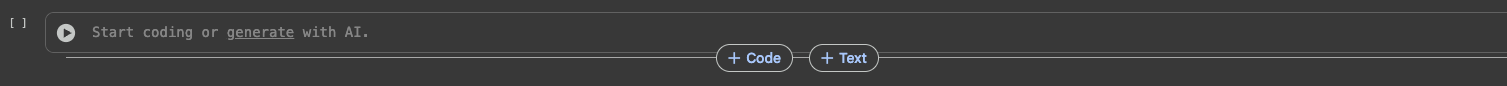